In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

df = pd.read_csv('../data/base2_anuncios_fazenda/farm-ads.csv')

df["target"] = (df["aprovado"] == 1).astype(int)

contagem_classes = df.groupby("target")["target"].count()
print(contagem_classes / contagem_classes.sum() * 100)

target
0    46.657012
1    53.342988
Name: target, dtype: float64


In [3]:
df.columns = df.columns.astype(str).str.strip().str.lower()

X = df["texto"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
print("Treinamento:", X_train.shape, " Teste:", X_test.shape)

validacao = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Treinamento: (3107,)  Teste: (1036,)


In [16]:
from sklearn.linear_model import LogisticRegression

pipe_logreg = Pipeline([
    ("tfidf", TfidfVectorizer(token_pattern=r"\b[A-Za-zÀ-ÿ]+\b")),
    ("clf", LogisticRegression(max_iter=2000, random_state=42)),
])

parametros_logreg = {
    "tfidf__max_features": [300, 500, 1000, 1500, 2000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "clf__C": [0.1, 0.3, 1, 3, 10],
    "tfidf__min_df": [1, 2, 5],
    "tfidf__max_df": [0.85, 0.9, 1.0],
    "tfidf__sublinear_tf": [True, False],
}

busca_logreg = RandomizedSearchCV(
    pipe_logreg, parametros_logreg, n_iter=15,
    scoring="f1", cv=validacao, random_state=42, n_jobs=1,
)
busca_logreg.fit(X_train, y_train)

print("Regressão Logística - melhores hiperparâmetros:", busca_logreg.best_params_)
print(f"Regressão Logística - f1 médio na validação: {busca_logreg.best_score_:.4f}")

Regressão Logística - melhores hiperparâmetros: {'tfidf__sublinear_tf': True, 'tfidf__ngram_range': (1, 1), 'tfidf__min_df': 1, 'tfidf__max_features': 2000, 'tfidf__max_df': 0.85, 'clf__C': 3}
Regressão Logística - f1 médio na validação: 0.9078


In [17]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("tfidf", TfidfVectorizer(token_pattern=r"\b[A-Za-zÀ-ÿ]+\b")),
    ("clf", RandomForestClassifier(random_state=42, n_jobs=-1)),
])

parametros_rf = {
    "tfidf__max_features": [500, 1000, 2000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "clf__n_estimators": [200, 300, 500],
    "clf__max_depth": [None, 20, 30],
    "clf__min_samples_leaf": [1, 2, 4],
    "tfidf__min_df": [1, 2, 5],
    "tfidf__max_df": [0.85, 0.9, 1.0],
    "tfidf__sublinear_tf": [True, False],
}

busca_rf = RandomizedSearchCV(
    pipe_rf, parametros_rf, n_iter=35,
    scoring="f1", cv=validacao, random_state=42, n_jobs=1,
)
busca_rf.fit(X_train, y_train)

print("Random Forest - melhores hiperparâmetros:", busca_rf.best_params_)
print("Random Forest - f1 médio na validação:", round(busca_rf.best_score_, 4))

Random Forest - melhores hiperparâmetros: {'tfidf__sublinear_tf': True, 'tfidf__ngram_range': (1, 1), 'tfidf__min_df': 2, 'tfidf__max_features': 500, 'tfidf__max_df': 0.9, 'clf__n_estimators': 500, 'clf__min_samples_leaf': 1, 'clf__max_depth': None}
Random Forest - f1 médio na validação: 0.9087


In [18]:
from sklearn.linear_model import SGDClassifier

pipe_sgd = Pipeline([
    ("tfidf", TfidfVectorizer(token_pattern=r"\b[A-Za-zÀ-ÿ]+\b")),
    ("clf", SGDClassifier(max_iter=2000, tol=1e-3, random_state=42)),
])

parametros_sgd = {
    "tfidf__max_features": [300, 500, 1000, 1500, 2000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2, 5],
    "tfidf__max_df": [0.85, 0.9, 1.0],
    "tfidf__sublinear_tf": [True, False],
    "clf__learning_rate": ["constant", "optimal", "adaptive"],
    "clf__loss": ["hinge", "log_loss"],
    "clf__alpha": [1e-5, 1e-4, 1e-3, 1e-2],
    "clf__penalty": ["l2", "l1", "elasticnet"],
    "clf__class_weight": [None, "balanced"],
}

busca_sgd = RandomizedSearchCV(
    pipe_sgd, parametros_sgd, n_iter=15,
    scoring="f1", cv=validacao, random_state=42, n_jobs=1,
)
busca_sgd.fit(X_train, y_train)

print("SGDClassifier - melhores hiperparâmetros:", busca_sgd.best_params_)
print("SGDClassifier - f1 médio na validação:", round(busca_sgd.best_score_, 4))

SGDClassifier - melhores hiperparâmetros: {'tfidf__sublinear_tf': True, 'tfidf__ngram_range': (1, 1), 'tfidf__min_df': 1, 'tfidf__max_features': 1000, 'tfidf__max_df': 0.9, 'clf__penalty': 'l2', 'clf__loss': 'hinge', 'clf__learning_rate': 'adaptive', 'clf__class_weight': 'balanced', 'clf__alpha': 0.0001}
SGDClassifier - f1 médio na validação: 0.9071


In [22]:
resultados = {
    "SGDClassifier": busca_sgd,
    "Regressão Logística": busca_logreg,
    "Random Forest": busca_rf,
}
for nome, busca in resultados.items():
    print(f"{nome:22s} recall médio (validação) = {busca.best_score_:.4f}")

melhor_nome = max(resultados, key=lambda k: resultados[k].best_score_)
melhor_modelo = resultados[melhor_nome].best_estimator_
print(f"\nModelo selecionado: {melhor_nome}")

SGDClassifier          recall médio (validação) = 0.9071
Regressão Logística    recall médio (validação) = 0.9078
Random Forest          recall médio (validação) = 0.9087

Modelo selecionado: Random Forest


Limiar de decisão utilizado nas métricas de classe prevista: 0.5
                     Acurácia  Precisão  Recall  F1-score  AUC-ROC  \
Modelo                                                               
SGDClassifier          0.8784    0.9261  0.8391    0.8805   0.9624   
Regressão Logística    0.8948    0.8801  0.9295    0.9041   0.9674   
Random Forest          0.8938    0.8686  0.9439    0.9047   0.9696   

                     AUC-PR (trapézio)  Average Precision (AP)  
Modelo                                                          
SGDClassifier                   0.9628                  0.9629  
Regressão Logística             0.9696                  0.9696  
Random Forest                   0.9730                  0.9730  


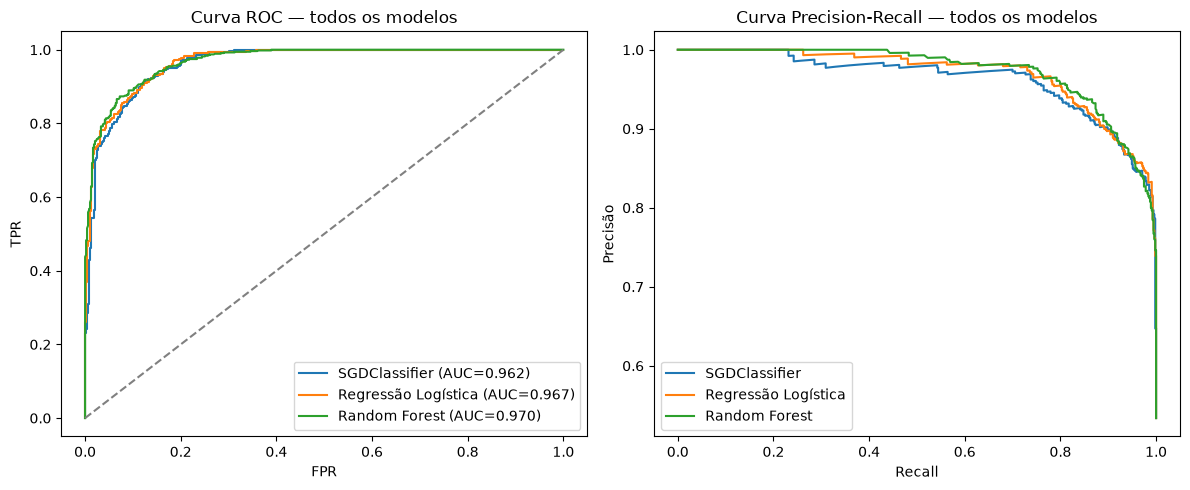

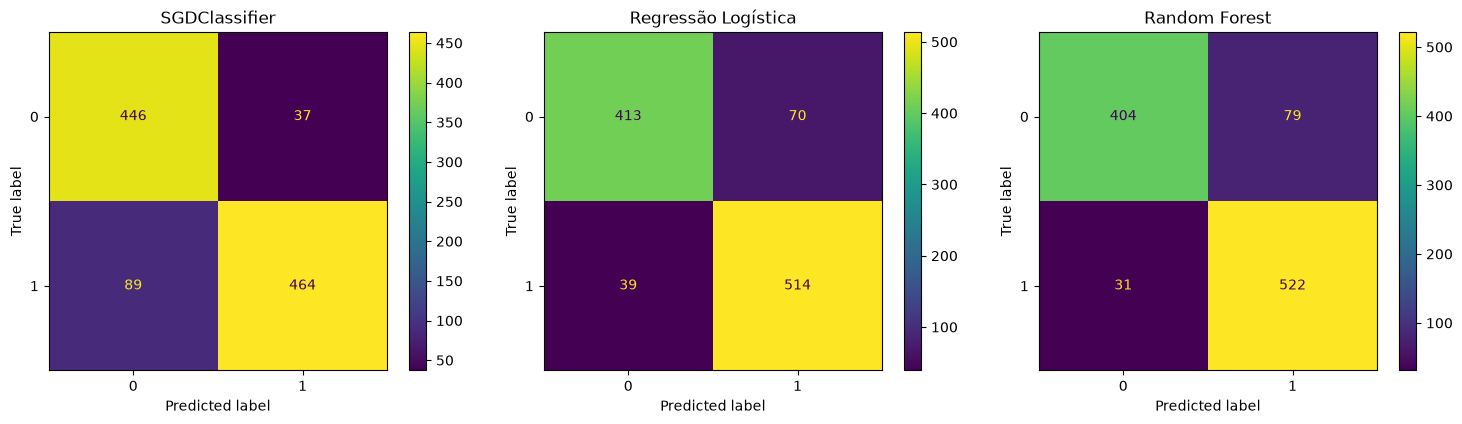

In [20]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, auc,
    average_precision_score, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt
import pandas as pd

LIMIAR = 0.5

linhas_metricas = []
curvas = {}

for nome, busca in resultados.items():
    modelo = busca.best_estimator_
    if hasattr(modelo, "predict_proba"):
        y_prob = modelo.predict_proba(X_test)[:, 1]
    else:
        y_prob = modelo.decision_function(X_test)
    y_pred = (y_prob >= LIMIAR).astype(int)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    precisao_c, recall_c, _ = precision_recall_curve(y_test, y_prob)

    auc_roc = roc_auc_score(y_test, y_prob)
    auc_pr = auc(recall_c, precisao_c)
    ap = average_precision_score(y_test, y_prob)

    linhas_metricas.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC-ROC": auc_roc,
        "AUC-PR (trapézio)": auc_pr,
        "Average Precision (AP)": ap,
    })

    curvas[nome] = dict(fpr=fpr, tpr=tpr, recall=recall_c, precisao=precisao_c,
                         auc_roc=auc_roc, y_pred=y_pred, y_prob=y_prob)

tabela_comparativa = pd.DataFrame(linhas_metricas).set_index("Modelo").round(4)
print(f"Limiar de decisão utilizado nas métricas de classe prevista: {LIMIAR}")
print(tabela_comparativa)

fig, eixos = plt.subplots(1, 2, figsize=(12, 5))
for nome, c in curvas.items():
    eixos[0].plot(c["fpr"], c["tpr"], label=f"{nome} (AUC={c['auc_roc']:.3f})")
    eixos[1].plot(c["recall"], c["precisao"], label=nome)

eixos[0].plot([0, 1], [0, 1], "--", color="gray")
eixos[0].set_title("Curva ROC — todos os modelos")
eixos[0].set_xlabel("FPR"); eixos[0].set_ylabel("TPR"); eixos[0].legend()

eixos[1].set_title("Curva Precision-Recall — todos os modelos")
eixos[1].set_xlabel("Recall"); eixos[1].set_ylabel("Precisão"); eixos[1].legend()

plt.tight_layout()
plt.show()

fig, eixos_cm = plt.subplots(1, len(curvas), figsize=(5 * len(curvas), 4))
for ax, (nome, c) in zip(eixos_cm, curvas.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, c["y_pred"], ax=ax)
    ax.set_title(nome)
plt.tight_layout()
plt.show()

100%|===================| 398/400 [01:04<00:00]        

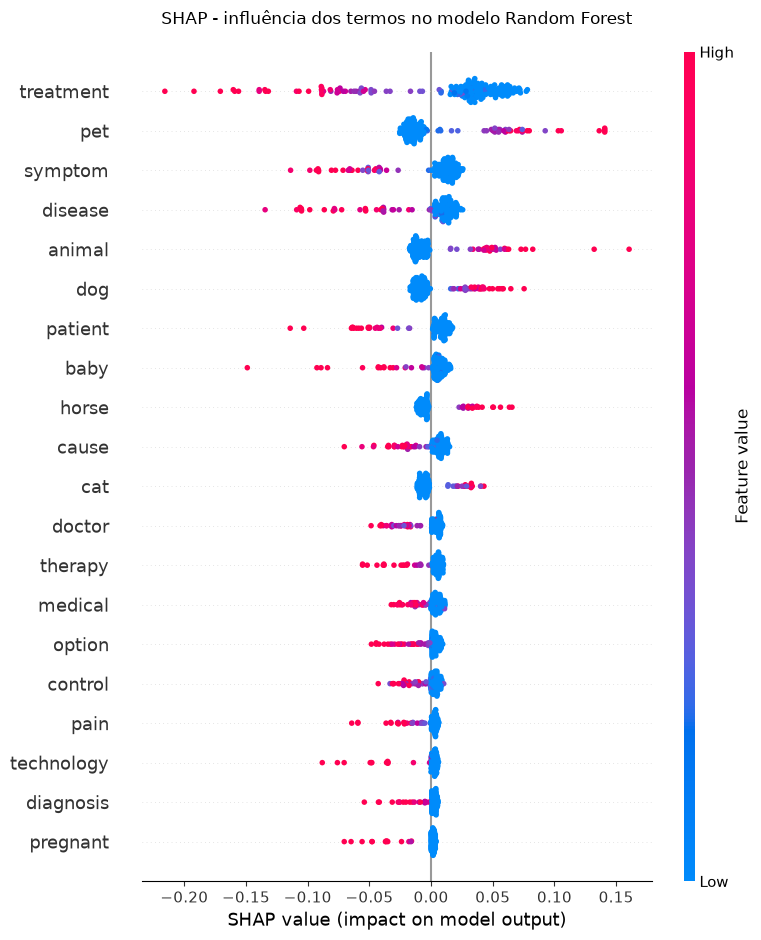

In [24]:
import shap

tfidf_ajustado = melhor_modelo.named_steps["tfidf"]
clf_ajustado = melhor_modelo.named_steps["clf"]
nomes_atributos = tfidf_ajustado.get_feature_names_out()

X_train_tfidf = tfidf_ajustado.transform(X_train).toarray()
X_test_tfidf = tfidf_ajustado.transform(X_test).toarray()
rng = np.random.default_rng(42)

indices_fundo = rng.choice(
    X_train_tfidf.shape[0], size=min(100, X_train_tfidf.shape[0]), replace=False
)
fundo = X_train_tfidf[indices_fundo]

indices_shap = rng.choice(
    X_test_tfidf.shape[0], size=min(200, X_test_tfidf.shape[0]), replace=False
)
X_shap = pd.DataFrame(X_test_tfidf[indices_shap], columns=nomes_atributos)

explainer = shap.TreeExplainer(
    clf_ajustado, fundo, feature_perturbation="interventional", model_output="probability"
)
valores_shap = explainer(X_shap, check_additivity=False)

if valores_shap.values.ndim == 3:
    valores_plot = valores_shap.values[:, :, 1]
else:
    valores_plot = valores_shap.values

shap.summary_plot(
    valores_plot, X_shap, feature_names=nomes_atributos,
    plot_type="dot", max_display=20, show=False,
 )
plt.title(f"SHAP - influência dos termos no modelo {melhor_nome}", pad=20)
plt.tight_layout()
plt.show()

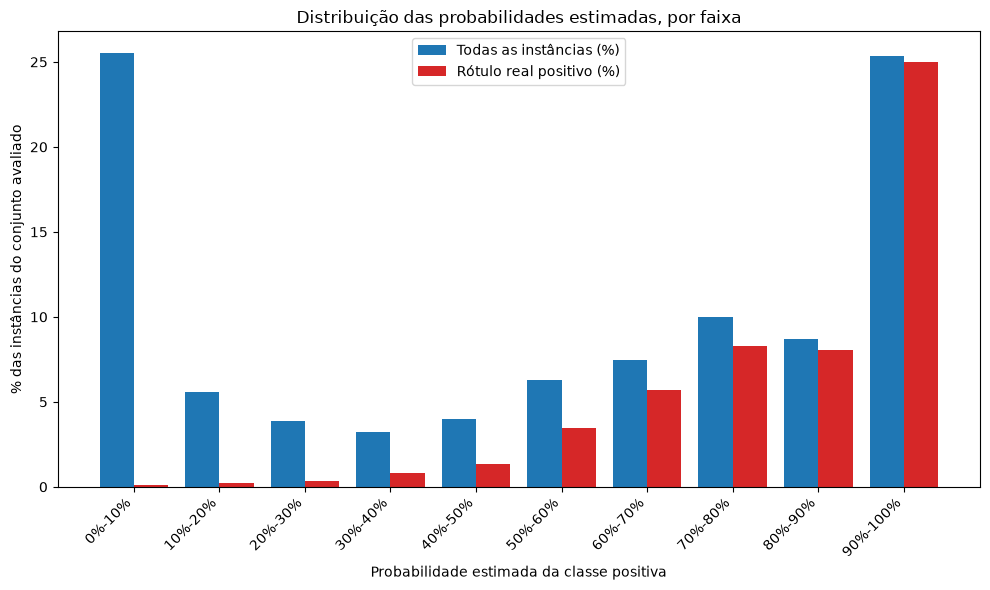

      faixa  qtd_total_por_faixa  pct_populacao_por_faixa  \
0    0%-10%                  793                25.523013   
1   10%-20%                  174                 5.600257   
2   20%-30%                  121                 3.894432   
3   30%-40%                  101                 3.250724   
4   40%-50%                  124                 3.990988   
5   50%-60%                  195                 6.276151   
6   60%-70%                  232                 7.467010   
7   70%-80%                  310                 9.977470   
8   80%-90%                  270                 8.690055   
9  90%-100%                  787                25.329900   

   qtd_positivos_por_faixa  pct_positivos_na_faixa  
0                        3                0.378310  
1                        7                4.022989  
2                       11                9.090909  
3                       26               25.742574  
4                       42               33.870968  
5         

In [25]:
import sys
import os

sys.path.append(os.path.abspath("../.."))

from parte1_grafico_pontos_corte.histograma_grafico_e_faixas import gerar_grafico_e_metricas

proba_oof = cross_val_predict(melhor_modelo, X_train, y_train, cv=validacao, method="predict_proba")[:, 1]

fig, ax, tabela_validacao, _ = gerar_grafico_e_metricas(y_train.values, proba_oof, bin_width=10)
plt.show()
print(tabela_validacao)

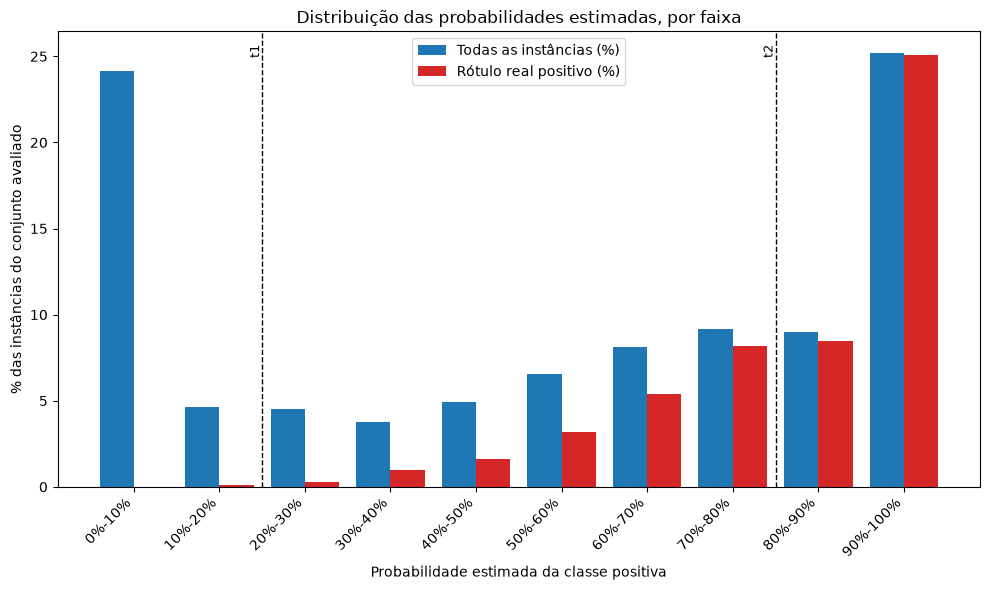

      faixa  qtd_total_por_faixa  pct_populacao_por_faixa  \
0    0%-10%                  250                24.131274   
1   10%-20%                   48                 4.633205   
2   20%-30%                   47                 4.536680   
3   30%-40%                   39                 3.764479   
4   40%-50%                   51                 4.922780   
5   50%-60%                   68                 6.563707   
6   60%-70%                   84                 8.108108   
7   70%-80%                   95                 9.169884   
8   80%-90%                   93                 8.976834   
9  90%-100%                  261                25.193050   

   qtd_positivos_por_faixa  pct_positivos_na_faixa  
0                        0                0.000000  
1                        1                2.083333  
2                        3                6.382979  
3                       10               25.641026  
4                       17               33.333333  
5         

In [26]:
melhor_modelo.fit(X_train, y_train)
proba_teste = melhor_modelo.predict_proba(X_test)[:, 1]

fig, ax, tabela_teste, metricas = gerar_grafico_e_metricas(
    y_test.values, proba_teste, bin_width=10, t1=20, t2=80
)
plt.show()
print(tabela_teste)
print(metricas)